## Create 3 sub DataFrames from the h5 file, monofil, quare, likelihood

In [2]:
import pandas as pd
import numpy as np
h5_path = r"C:\Python Programming\LIU\projects\hrnet_w48_2024_11_18\squaretest_convertedDLC_HrnetW48_hrnet_w48_2Nov18shuffle1_snapshot_100.h5"
df = pd.read_hdf(h5_path)
df.columns = [f"{bodypart}_{coord}" for bodypart, coord in zip(df.columns.get_level_values(1), df.columns.get_level_values(2))]
df_monofil = df.loc[:, df.columns.str.startswith(('FR', 'FG', 'FB')) & ~df.columns.str.endswith('likelihood')]
df_square = df.loc[:, df.columns.str.startswith(('Top_left', 'Top_right', 'Bottom_left', 'Bottom_right')) & ~df.columns.str.endswith('likelihood')]
df_likelihoods = df.loc[:, df.columns.str.endswith('likelihood')]
overall_average = df_likelihoods.mean().mean()
print("Overall Average Likelihood:", overall_average)
bodypart_means = df_likelihoods.mean(axis=0)
print("Mean likelihood for each body part:")
print(bodypart_means)

Overall Average Likelihood: 0.94016236
Mean likelihood for each body part:
FR1_likelihood             0.912168
FR2_likelihood             0.925243
FG1_likelihood             0.918280
FG2_likelihood             0.899722
FB1_likelihood             0.923611
FB2_likelihood             0.918242
Top_left_likelihood        0.989929
Top_right_likelihood       0.946855
Bottom_left_likelihood     0.992007
Bottom_right_likelihood    0.975567
dtype: float32


### Visualizer Outliers

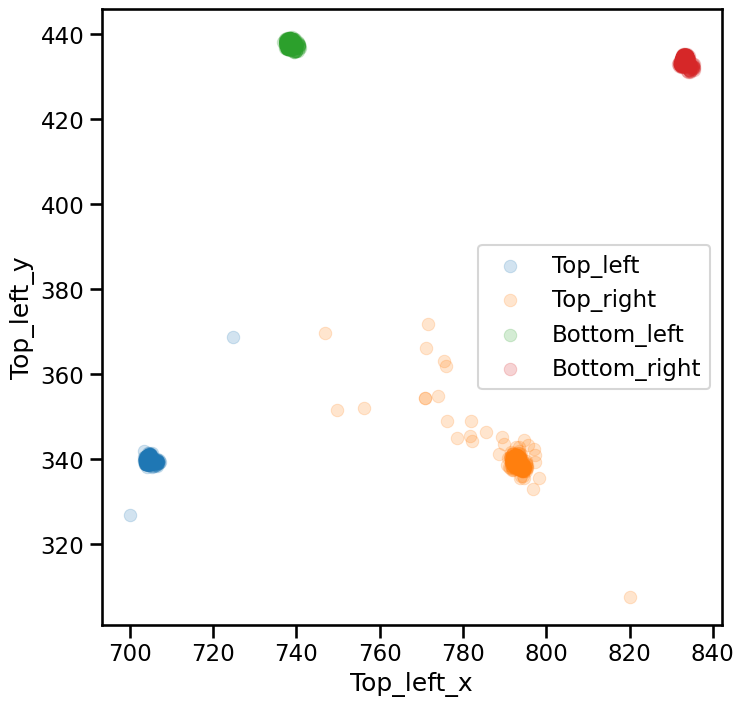

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_square_scatter(df, figsize=(8, 8)):
    # Plotting the scatter plot for all the body parts of the square
    sns.set_context("talk")
    plt.figure(figsize=figsize)
    sns.scatterplot(data=df, x='Top_left_x', y='Top_left_y', label='Top_left',
                    alpha=0.2, edgecolor=None)
    sns.scatterplot(data=df, x='Top_right_x', y='Top_right_y', label='Top_right',
                    alpha=0.2, edgecolor=None)
    sns.scatterplot(data=df, x='Bottom_left_x', y='Bottom_left_y', label='Bottom_left',
                    alpha=0.2, edgecolor=None)
    sns.scatterplot(data=df, x='Bottom_right_x', y='Bottom_right_y', label='Bottom_right',
                    alpha=0.2, edgecolor=None)
    plt.legend()
    plt.show()

# create scatter plot of all the square body parts to see if there ARE any outliers
plot_square_scatter(df_square)

### Impute outliers v.1

In [4]:
from sklearn.linear_model import RANSACRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
#! It just gets very loud with all the warnings of float types, so I'm ignoring them for now

# Function to train ML model and predict missing values
def impute_with_ml(df, target_col, model = "RFR"):
    """
    Impute missing values in a DataFrame using machine learning.

    args:
    - df: DataFrame with missing values to predict
    - target_col: Column name with missing values to predict
    - model: Model to use for prediction (RFR, HGBR, KNR)
        RFR = RandomForestRegressor
        HGBR = HistGradientBoostingRegressor
        KNR = KNeighborsRegressor
    """
    df_copy = df.copy()
    
    # Identify rows with and without missing values
    train_df = df_copy.dropna()  # Frames with no missing points
    test_df = df_copy[df_copy[target_col].isna()]  # Frames with missing values
    

    if test_df.empty:
        return df_copy  # No missing values to predict

    # Define input features (other 6 points)
    feature_cols = [col for col in df_copy.columns if col != target_col]

    # Train-test split
    X_train, y_train = train_df[feature_cols], train_df[target_col]

    # Train model
    if model == "RFR":
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
    elif model == "HGBR":
        model = HistGradientBoostingRegressor()
        model.fit(X_train, y_train)
        
    # Predict missing values
    df_copy.loc[df_copy[target_col].isna(), target_col] = model.predict(test_df[feature_cols])

    return df_copy

def impute_outliers(df, method="square", std_threshold=2.0, model = "RFR"):
    """
    Detect outliers in a square or filament dataset and impute them
    using machine learning.

    args:
    - df: DataFrame with x and y columns for each body part
    - method: "square" or "filament" to specify the type of dataset
    - std_threshold: Number of standard deviations from the mean to
        consider as outlier
    - model: Model to use for prediction (RFR, HGBR, KNR)
        RFR = RandomForestRegressor
        HGBR = HistGradientBoostingRegressor
        KNR = KNeighborsRegressor
    """
    df_copy = df.copy()
    
    x_cols = df_copy.columns[df_copy.columns.str.contains("x")].tolist()
    y_cols = df_copy.columns[df_copy.columns.str.contains("y")].tolist()

    valid_rows = df_copy.dropna(subset=x_cols + y_cols, how="all")

    if valid_rows.empty:
        print("No valid rows for RANSAC. Returning original DataFrame.")
        return df  # If no valid data remains, return original

    if method == "square":
        # Compute angles for each corner
        valid_rows["angle_TL"] = np.arctan2(valid_rows[y_cols[0]] - valid_rows[y_cols[1]],
                                            valid_rows[x_cols[0]] - valid_rows[x_cols[1]])  # TL to TR
        valid_rows["angle_TR"] = np.arctan2(valid_rows[y_cols[1]] - valid_rows[y_cols[3]],
                                            valid_rows[x_cols[1]] - valid_rows[x_cols[3]])  # TR to BR
        valid_rows["angle_BR"] = np.arctan2(valid_rows[y_cols[3]] - valid_rows[y_cols[2]],
                                            valid_rows[x_cols[3]] - valid_rows[x_cols[2]])  # BR to BL
        valid_rows["angle_BL"] = np.arctan2(valid_rows[y_cols[2]] - valid_rows[y_cols[0]],
                                            valid_rows[x_cols[2]] - valid_rows[x_cols[0]])  # BL to TL

        # Compute mean and std for each angle
        angle_means = valid_rows[["angle_TL", "angle_TR", "angle_BR", "angle_BL"]].mean()
        angle_stds = valid_rows[["angle_TL", "angle_TR", "angle_BR", "angle_BL"]].std()

        # Identify outliers for each corner
        outlier_TL = abs(valid_rows["angle_TL"] - angle_means["angle_TL"]) > std_threshold * angle_stds["angle_TL"]
        outlier_TR = abs(valid_rows["angle_TR"] - angle_means["angle_TR"]) > std_threshold * angle_stds["angle_TR"]
        outlier_BR = abs(valid_rows["angle_BR"] - angle_means["angle_BR"]) > std_threshold * angle_stds["angle_BR"]
        outlier_BL = abs(valid_rows["angle_BL"] - angle_means["angle_BL"]) > std_threshold * angle_stds["angle_BL"]

        # Instead of setting the whole row to NaN, set only the specific outlier points
        valid_rows.loc[outlier_TL, [x_cols[0], y_cols[0]]] = np.nan
        valid_rows.loc[outlier_TR, [x_cols[1], y_cols[1]]] = np.nan
        valid_rows.loc[outlier_BR, [x_cols[3], y_cols[3]]] = np.nan
        valid_rows.loc[outlier_BL, [x_cols[2], y_cols[2]]] = np.nan

        #print(valid_rows.isna().sum())

    if method == "filament":
        # Define point groups (pairs of 2 points each, so 4 columns at a time)
        point_groups = [
            (x_cols[0:2] + y_cols[0:2]),  # First 2 points
            (x_cols[2:4] + y_cols[2:4]),  # Middle 2 points
            (x_cols[4:6] + y_cols[4:6])   # Last 2 points
        ]
        
        for group in point_groups:
            ransac = RANSACRegressor()
            X = np.arange(len(valid_rows)).reshape(-1, 1)
            y = valid_rows[group].mean(axis=1)  # Use mean of x,y values for reference
            
            ransac.fit(X, y)
            inlier_mask = ransac.inlier_mask_
            outlier_mask = ~inlier_mask
            
            # Set only specific outlier columns to NaN instead of whole row
            valid_rows.loc[outlier_mask, group] = np.nan

    # Use impute_with_ml for advanced interpolation
    for col in x_cols + y_cols:
        valid_rows = impute_with_ml(valid_rows, col, model)

    df_copy.update(valid_rows.astype(np.float32))

    return df_copy

### Impute Outliers v.2

In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RANSACRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

# Compute angles using column positions
# Takes a dataframe and a list of column index pairs, returning computed angles
def compute_angles(df, pairs):
    angles = []
    for pair in pairs:
        x1 = df.iloc[:, pair[0]]  # Extract x-coordinates of first point
        y1 = df.iloc[:, pair[1]]  # Extract y-coordinates of first point
        x2 = df.iloc[:, pair[2]]  # Extract x-coordinates of second point
        y2 = df.iloc[:, pair[3]]  # Extract y-coordinates of second point
        angle = np.arctan2(y2 - y1, x2 - x1)  # Compute the angle between points
        angles.append(angle)
    return np.column_stack(angles)

# Outlier detection for square using standard deviation on angles
def detect_outliers_square_std(valid_rows, pairs, std_threshold=2.0):
    angles = compute_angles(valid_rows, pairs)  # Compute angles for provided point pairs
    n_angles = angles.shape[1]
    angle_df = pd.DataFrame(angles, columns=[f"angle_{i+1}" for i in range(n_angles)], index=valid_rows.index)
    angle_means = angle_df.mean()
    angle_stds = angle_df.std()
    
    # Identify and replace outliers based on standard deviation threshold
    for i in range(n_angles):
        outlier_mask = (angle_df.iloc[:, i] - angle_means.iloc[i]).abs() > std_threshold * angle_stds.iloc[i]
        dest_x, dest_y = pairs[i][2], pairs[i][3]
        col_x, col_y = valid_rows.columns[dest_x], valid_rows.columns[dest_y]
        valid_rows.loc[outlier_mask, [col_x, col_y]] = np.nan

    print(f"{valid_rows.isna().sum()} \nmissing values after outlier detection")
    return valid_rows

# Outlier detection for square using RANSAC on angles
def detect_outliers_square_ransac(valid_rows, pairs,
                                  min_samples = None,
                                  residual_threshold = None,
                                  max_trials = 100):
    angles = compute_angles(valid_rows, pairs)
    n_angles = angles.shape[1]
    angle_df = pd.DataFrame(angles, columns=[f"angle_{i+1}" for i in range(n_angles)], index=valid_rows.index)
    inlier_mask = np.ones(len(valid_rows), dtype=bool)
    
    # Apply RANSAC regression to identify inliers
    for col in angle_df.columns:
        ransac = RANSACRegressor(
            min_samples=min_samples,
            residual_threshold=residual_threshold,
            max_trials=max_trials
            )
        X = np.arange(len(valid_rows)).reshape(-1, 1)
        y = angle_df[col]
        ransac.fit(X, y)
        inlier_mask &= ransac.inlier_mask_
    
    valid_rows.loc[~inlier_mask, valid_rows.columns[:8]] = np.nan
    print(f"{valid_rows.isna().sum()} \nmissing values after outlier detection")
    return valid_rows

# Outlier detection for filament using RANSAC on point groups
def detect_outliers_filament_ransac(valid_rows, pairs,
                                    min_samples = None,
                                    residual_threshold = None,
                                    max_trials = 100):
    angles = compute_angles(valid_rows, pairs)
    n_angles = angles.shape[1]
    angle_df = pd.DataFrame(angles, columns=[f"angle_{i+1}" for i in range(n_angles)], index=valid_rows.index)
    inlier_mask = np.ones(len(valid_rows), dtype=bool)

    # Apply RANSAC regression to identify inliers
    for i, col in enumerate(angle_df.columns):
        ransac = RANSACRegressor(
            min_samples=min_samples,
            residual_threshold=residual_threshold,
            max_trials=max_trials
            )
        X = np.arange(len(valid_rows)).reshape(-1, 1)
        y = angle_df[col]
        ransac.fit(X, y)
        inlier_mask &= ransac.inlier_mask_

        # Set specific outlier points to NaN
        outlier_mask = ~ransac.inlier_mask_
        dest_x1, dest_y1 = pairs[i][0], pairs[i][1]
        dest_x2, dest_y2 = pairs[i][2], pairs[i][3]
        col_x1, col_y1 = valid_rows.columns[dest_x1], valid_rows.columns[dest_y1]
        col_x2, col_y2 = valid_rows.columns[dest_x2], valid_rows.columns[dest_y2]
        valid_rows.loc[outlier_mask, [col_x1, col_y1, col_x2, col_y2]] = np.nan

    print(f"{valid_rows.isna().sum()} \nmissing values after outlier detection")
    return valid_rows

# Impute missing values using machine learning
def impute_with_ml(df, target_col, model="RFR"):
    df_copy = df.copy()
    train_df = df_copy.dropna()
    test_df = df_copy[df_copy[target_col].isna()]
    
    if test_df.empty:
        return df_copy
    
    feature_cols = [col for col in df_copy.columns if col != target_col]
    X_train, y_train = train_df[feature_cols], train_df[target_col]
    
    # Select regression model
    if model == "RFR":
        ml_model = RandomForestRegressor(n_estimators=100, random_state=42)
    elif model == "HGBR":
        ml_model = HistGradientBoostingRegressor()
    elif model == "KNR":
        ml_model = KNeighborsRegressor(n_neighbors=10)
    else:
        raise ValueError("Invalid model parameter. Use RFR, HGBR, or KNR.")
    
    ml_model.fit(X_train, y_train)
    df_copy.loc[df_copy[target_col].isna(), target_col] = ml_model.predict(test_df[feature_cols])
    
    return df_copy

def get_square_pairs():
    square_pairs = [
        [0, 1, 2, 3],  # angle from TL (columns 0,1) to TR (columns 2,3)
        [2, 3, 6, 7],  # angle from TR (2,3) to BR (6,7)
        [6, 7, 4, 5],  # angle from BR (6,7) to BL (4,5)
        [4, 5, 0, 1]   # angle from BL (4,5) back to TL (0,1)
    ]
    return square_pairs

def get_filament_pairs():
    monofil_pairs = [
        [0, 1, 2, 3],    # angle between point 1 (cols 0,1) and point 2 (cols 2,3)
        #[2, 3, 4, 5],    # angle between point 2 (cols 2,3) and point 3 (cols 4,5)
        [4, 5, 6, 7],    # angle between point 3 (cols 4,5) and point 4 (cols 6,7)
        #[6, 7, 8, 9],    # angle between point 4 (cols 6,7) and point 5 (cols 8,9)
        [8, 9, 10, 11]   # angle between point 5 (cols 8,9) and point 6 (cols 10,11)
    ]
    return monofil_pairs

# Main function to detect and impute outliers
def impute_outliers(df,
                    method="square",
                    std_threshold=2.0,
                    model="RFR",
                    min_samples=None,
                    residual_threshold=None,
                    max_trials=100
                    ):
    df_copy = df.copy()
    valid_rows = df_copy.dropna(how="all")
    print(f"{valid_rows.isna().sum()} \nmissing values before outlier detection")
    
    if valid_rows.empty:
        print("No valid rows for outlier detection. Returning original DataFrame.")
        return df_copy
    
    if method == "square_std":
        valid_rows = detect_outliers_square_std(
            valid_rows,
            get_square_pairs(),
            std_threshold
            )
    elif method == "square_ransac":
        valid_rows = detect_outliers_square_ransac(
            valid_rows,
            get_square_pairs(),
            min_samples = min_samples,
            residual_threshold = residual_threshold,
            max_trials = max_trials
            )
    elif method == "filament":
        valid_rows = detect_outliers_filament_ransac(
            valid_rows,
            get_filament_pairs(),
            min_samples = min_samples,
            residual_threshold = residual_threshold,
            max_trials = max_trials
            )
    
    for col in df_copy.columns:
        valid_rows = impute_with_ml(valid_rows, col, model)
    
    df_copy.update(valid_rows.astype(np.float32))
    return df_copy

#### Imputing outliers for square

Top_left_x        0
Top_left_y        0
Top_right_x       0
Top_right_y       0
Bottom_left_x     0
Bottom_left_y     0
Bottom_right_x    0
Bottom_right_y    0
dtype: int64 
missing values before outlier detection
Top_left_x        173
Top_left_y        173
Top_right_x        24
Top_right_y        24
Bottom_left_x     298
Bottom_left_y     298
Bottom_right_x     21
Bottom_right_y     21
dtype: int64 
missing values after outlier detection


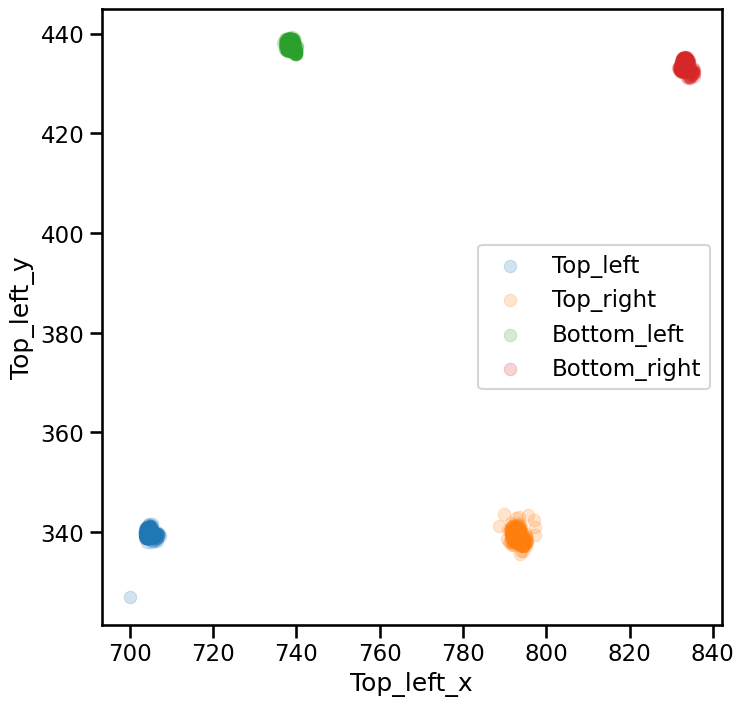

In [11]:
df_square_rfr = impute_outliers(df_square, method="square_std", std_threshold=1, model="RFR")
plot_square_scatter(df_square_rfr)

Top_left_x        0
Top_left_y        0
Top_right_x       0
Top_right_y       0
Bottom_left_x     0
Bottom_left_y     0
Bottom_right_x    0
Bottom_right_y    0
dtype: int64 
missing values before outlier detection
Top_left_x        173
Top_left_y        173
Top_right_x        24
Top_right_y        24
Bottom_left_x     298
Bottom_left_y     298
Bottom_right_x     21
Bottom_right_y     21
dtype: int64 
missing values after outlier detection


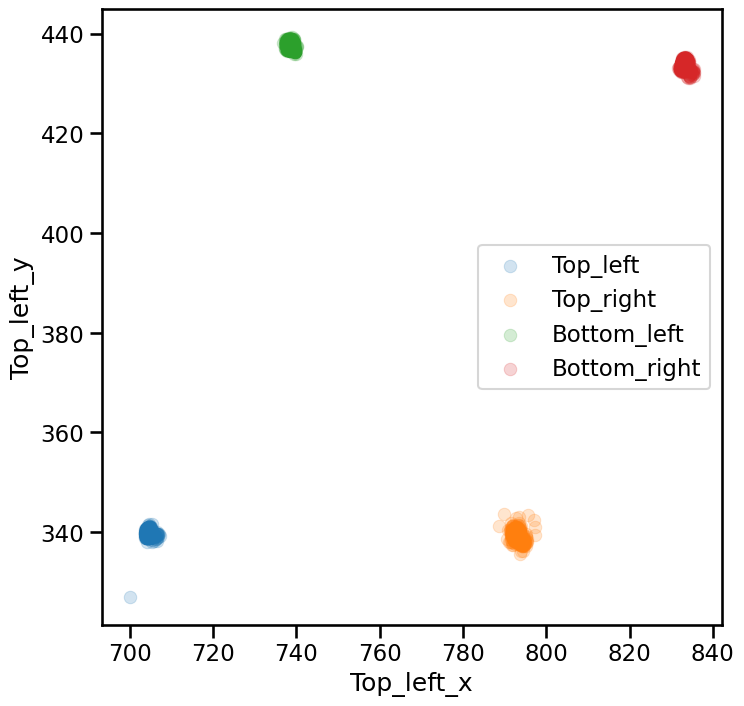

In [12]:
df_square_rfr = impute_outliers(df_square, method="square_std", std_threshold=1, model="HGBR")
plot_square_scatter(df_square_rfr)

Top_left_x        0
Top_left_y        0
Top_right_x       0
Top_right_y       0
Bottom_left_x     0
Bottom_left_y     0
Bottom_right_x    0
Bottom_right_y    0
dtype: int64 
missing values before outlier detection
Top_left_x        325
Top_left_y        325
Top_right_x       325
Top_right_y       325
Bottom_left_x     325
Bottom_left_y     325
Bottom_right_x    325
Bottom_right_y    325
dtype: int64 
missing values after outlier detection


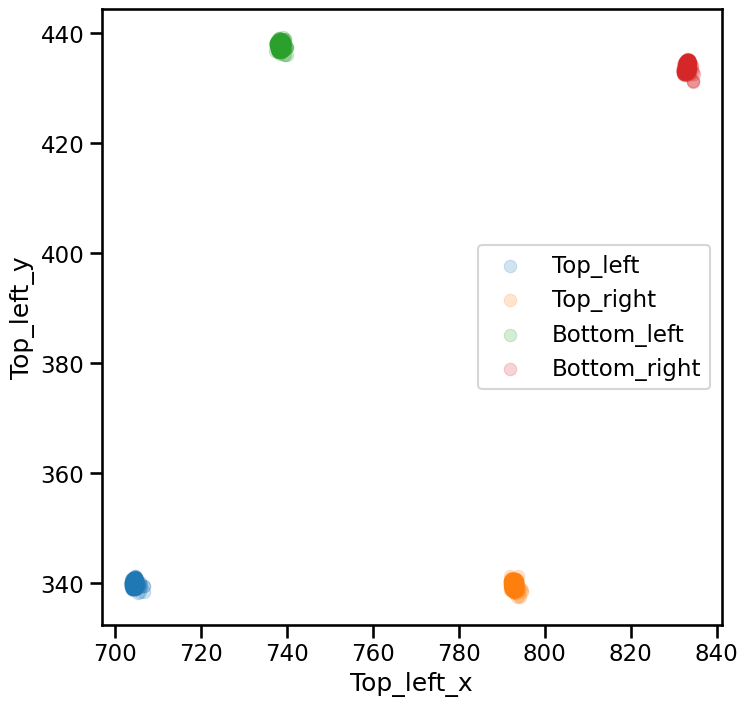

In [14]:
df_square_rfr = impute_outliers(df_square, method="square_ransac", model="RFR",
                                min_samples=10, residual_threshold=0.009, max_trials=300)
plot_square_scatter(df_square_rfr)

Top_left_x        0
Top_left_y        0
Top_right_x       0
Top_right_y       0
Bottom_left_x     0
Bottom_left_y     0
Bottom_right_x    0
Bottom_right_y    0
dtype: int64 
missing values before outlier detection
Top_left_x        314
Top_left_y        314
Top_right_x       314
Top_right_y       314
Bottom_left_x     314
Bottom_left_y     314
Bottom_right_x    314
Bottom_right_y    314
dtype: int64 
missing values after outlier detection


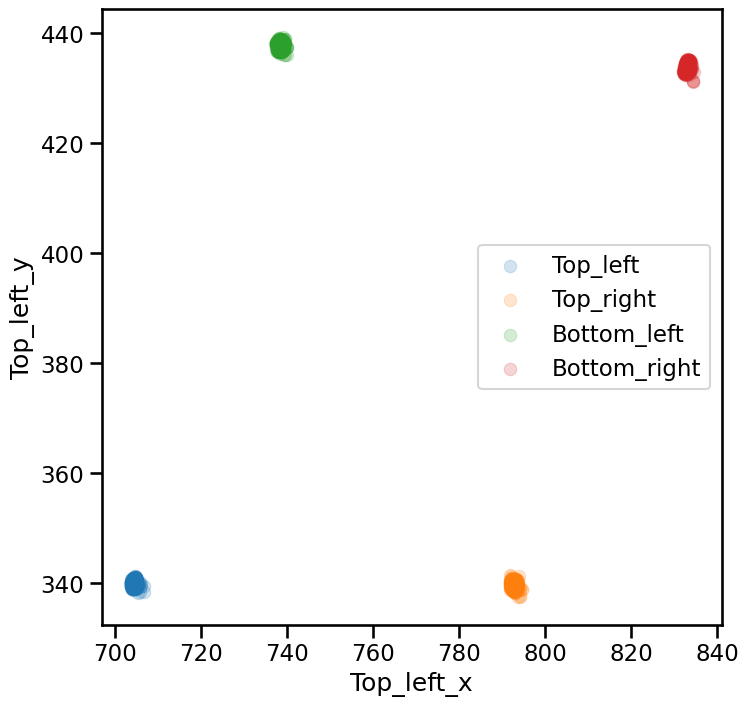

In [13]:
df_square_hgbr = impute_outliers(df_square, method="square_ransac", model="HGBR",
                                min_samples=10, residual_threshold=0.009, max_trials=300)
plot_square_scatter(df_square_hgbr)

#### Imputing outliers for filament

In [15]:
df_monofil_cleaned = impute_outliers(df_monofil, method="filament", std_threshold=1, model="RFR",
                                min_samples=30, residual_threshold=2, max_trials=400)

FR1_x    0
FR1_y    0
FR2_x    0
FR2_y    0
FG1_x    0
FG1_y    0
FG2_x    0
FG2_y    0
FB1_x    0
FB1_y    0
FB2_x    0
FB2_y    0
dtype: int64 
missing values before outlier detection
FR1_x    36
FR1_y    36
FR2_x    36
FR2_y    36
FG1_x    17
FG1_y    17
FG2_x    17
FG2_y    17
FB1_x     4
FB1_y     4
FB2_x     4
FB2_y     4
dtype: int64 
missing values after outlier detection


## Visualizing the imputed outliers

In [16]:
import cv2
import pandas as pd

def draw_dots_on_frame(frame, row, x_cols, y_cols, color):
    """
    Draw dots on the frame based on the coordinates in the DataFrame row.

    args:
    - frame: The video frame to draw on.
    - row: A single row from the DataFrame containing the coordinates of the dots.
    - x_cols: List of x-coordinate column names.
    - y_cols: List of y-coordinate column names.
    - color: Color of the dots (BGR tuple).
    """
    for x_col, y_col in zip(x_cols, y_cols):
        x, y = int(row[x_col]), int(row[y_col])
        cv2.circle(frame, (x, y), radius=5, color=color, thickness=-1)

def process_video(input_video_path, output_video_path, df_square, df_monofil):
    """
    Process the video by drawing dots on each frame based on the DataFrames.

    args:
    - input_video_path: Path to the input video file.
    - output_video_path: Path to save the output video file.
    - df_square: DataFrame containing coordinates for square dots.
    - df_monofil: DataFrame containing coordinates for monofil dots.
    """
    # Open the original video
    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    # Get video properties
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

    # Get the x and y columns for both DataFrames
    x_cols_square = df_square.columns[df_square.columns.str.contains("x")].tolist()
    y_cols_square = df_square.columns[df_square.columns.str.contains("y")].tolist()
    x_cols_monofil = df_monofil.columns[df_monofil.columns.str.contains("x")].tolist()
    y_cols_monofil = df_monofil.columns[df_monofil.columns.str.contains("y")].tolist()

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx < len(df_square):
            draw_dots_on_frame(frame, df_square.iloc[frame_idx], x_cols_square, y_cols_square, color=(0, 255, 0))  # Green dots for df_square

        if frame_idx < len(df_monofil):
            draw_dots_on_frame(frame, df_monofil.iloc[frame_idx], x_cols_monofil, y_cols_monofil, color=(0, 0, 255))  # Red dots for df_monofil

        # Write the frame to the output video
        out.write(frame)
        frame_idx += 1

    # Release the video objects
    cap.release()
    out.release()
    print("Video processing complete. Saved to:", output_video_path)

# Example usage
input_video_path = r'C:\\Python Programming\\LIU\\projects\\hrnet_w48_2024_11_18\\squaretest_convertedDLC_HrnetW48_hrnet_w48_2Nov18shuffle1_snapshot_100_p50_labeled.mp4'
output_video_path = r'C:\\Python Programming\\LIU\\projects\\hrnet_w48_2024_11_18\\squaretest_convertedDLC_HrnetW48_hrnet_w48_2Nov18shuffle1_snapshot_100_p50_relabeled.mp4'

process_video(input_video_path, output_video_path, df_square_hgbr, df_monofil_cleaned)

Video processing complete. Saved to: C:\\Python Programming\\LIU\\projects\\hrnet_w48_2024_11_18\\squaretest_convertedDLC_HrnetW48_hrnet_w48_2Nov18shuffle1_snapshot_100_p50_relabeled.mp4
